## Graphical abstract

UMAP + cluster-coloring and pie-chart plots used for the paper's graphical abstract,
extracted from `figure_5_main`. Run the imports + data-loading cells first.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import seaborn as sns

sns.set_context('notebook', font_scale=1.5, rc={'lines.markeredgewidth': 1})

# Visual behavior analysis package functions
import visual_behavior.visualization.utils as utils
import visual_behavior.data_access.loading as loading
import visual_behavior.data_access.utilities as utilities

# Clustering modules
from visual_behavior.dimensionality_reduction.clustering import plotting
from visual_behavior.dimensionality_reduction.clustering import processing

# Platform paper figure functions
import visual_behavior.visualization.ophys.platform_paper_figures as ppf
import visual_behavior.visualization.ophys.platform_single_cell_examples as pse

%load_ext autoreload
%autoreload 2
%matplotlib inline

/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/xarray/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/from_lims.py:37: UserWarning: failed to set up LIMS/mtrain 

In [2]:
# Figure saving
save_dir = os.path.join(loading.get_figures_save_dir(), 'platform_paper_figures', 'figure_5')
os.makedirs(save_dir, exist_ok=True)

## Data Loading

#### Metadata tables

In [3]:
# AllenSDK cache
platform_cache_dir = loading.get_platform_analysis_cache_dir()
cache = loading._get_cache()

# Curated metadata tables
metadata_tables_dir = loading.get_metadata_tables_dir()
experiments_table = pd.read_csv(os.path.join(metadata_tables_dir, 'all_ophys_experiments_table.csv'), index_col=0)
platform_experiments = pd.read_csv(os.path.join(metadata_tables_dir, 'platform_paper_ophys_experiments_table.csv'), index_col=0)
platform_cells_table = pd.read_csv(os.path.join(metadata_tables_dir, 'platform_paper_ophys_cells_table.csv'), index_col=0)
matched_cells_table = pd.read_csv(os.path.join(metadata_tables_dir, 'platform_paper_matched_ophys_cells_table.csv'), index_col=0)

# Relevant IDs
matched_cells = matched_cells_table.cell_specimen_id.unique()
matched_experiments = matched_cells_table.ophys_experiment_id.unique()

# Cre lines, cell types, and palette for plotting
cre_lines = np.sort(platform_cells_table.cre_line.unique())
cell_types = utils.get_cell_types()
experience_levels = utils.get_experience_levels()
palette = utils.get_experience_level_colors()


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

#### Clustering results, coding scores, UMAP

In [4]:
glm_results_dir = loading.get_glm_results_dir()
clustering_dir = loading.get_clustering_results_dir()
data_dir = loading.get_clustering_results_dir()

# Load clustering results
feature_matrix = pd.read_hdf(os.path.join(data_dir, 'clustering_feature_matrix.h5'), key='df')
feature_matrix = feature_matrix.rename(columns={'all-images': 'images', 'behavioral': 'behavior'})

n_clusters = 14
cluster_meta = pd.read_hdf(os.path.join(data_dir, f'cluster_metadata_{n_clusters}_clusters.h5'), key='df')

original_feature_matrix = feature_matrix.copy()
original_cluster_meta = cluster_meta.copy()

# Load coding scores - normalized for clustering
results_pivoted = pd.read_hdf(os.path.join(glm_results_dir, 'across_session_normalized_platform_results_pivoted.h5'), key='df')
all_results = pd.read_hdf(os.path.join(glm_results_dir, 'all_results.h5'), key='df')

# Load UMAP results
umap_df = processing.get_umap_results(feature_matrix, cluster_meta, save_dir=clustering_dir, suffix='')

loading umap results from /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_clustering_results/umap_results_df.h5


### Graphical abstract

In [ ]:
import umap

In [ ]:
umap_df = processing.get_umap_results(feature_matrix, cluster_meta, save_dir=data_dir, suffix='')

loading umap results from /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_clustering_results/umap_results_df.h5


In [ ]:
# limit cluster meta to cells that are not in cluster 1 (which is an outlier in the plot)
main_cluster_meta = cluster_meta[cluster_meta.cluster_id!=1]
# limit umap_df to non-cluster 1
umap_df['cell_specimen_id'] = cluster_meta.index.values
umap_df = umap_df.set_index('cell_specimen_id')
umap_df = umap_df.loc[main_cluster_meta.index.values]
umap_df['cell_type'] = main_cluster_meta['cell_type']
# identify other non-outlier points and limit both tables to those
csids = umap_df[umap_df.x<16].index.values
main_cluster_meta = main_cluster_meta.loc[csids]
umap_df = umap_df.loc[csids]
print(len(umap_df), len(main_cluster_meta))
umap_df.head()

2941 2941


,x,y,cluster_id,cell_type
cell_specimen_id,,,,
1086489847,4.780380,7.625232,12,Vip Inhibitory
1086489860,9.371953,2.737884,2,Vip Inhibitory
1086489891,4.785028,7.619345,12,Vip Inhibitory
1086489976,6.144250,11.332527,4,Sst Inhibitory
1086490002,9.028252,10.901272,4,Sst Inhibitory


In [ ]:
exp_colors = utils.get_experience_level_colors()
gray = (0.8, 0.8, 0.8)
cluster_color_dict = {1: gray, # non coding - gray
                      2: exp_colors[1], # novel image coding - red
                      3: exp_colors[2], # persistent novel image coding - purple 
                      4: exp_colors[0], # familiar image coding - blue
                      5: exp_colors[2], # novel+ image coding - purple 
                      6: exp_colors[2], # novelty suppression - purple
                      7: exp_colors[1], # novel image (+familiar) coding - red
                      8: exp_colors[0], # omission coding during familiar - blue
                      9: exp_colors[2], # omission coding during novel+ - purple
                      10: exp_colors[0], # task coding during familiar - blue
                      11: exp_colors[1], # novel task coding - red
                      12: gray, # behavior coding - gray
                      }
exp_colors = [cluster_color_dict[main_cluster_meta.loc[cell_specimen_id]['cluster_id']] for cell_specimen_id in main_cluster_meta.index.values]


feature_colors = plotting.get_feature_colors_with_gray()
feature_color_dict = {1: gray, # non coding - gray
                      2: feature_colors[1], # image coding
                      3: feature_colors[1], # image coding
                      4: feature_colors[1], # image coding
                      5: feature_colors[1], # image coding 
                      6: feature_colors[1], # image coding 
                      7: feature_colors[1], # image coding 
                      8: feature_colors[2], # omission coding
                      9: feature_colors[2], # omission coding
                      10: feature_colors[3], # task coding
                      11: feature_colors[3], # task coding
                      12: feature_colors[4], # behavior coding
                      }

feature_colors = [feature_color_dict[main_cluster_meta.loc[cell_specimen_id]['cluster_id']] for cell_specimen_id in main_cluster_meta.index.values]

meaningful_labels_dict = {1: '', # non coding - gray
                2: 'novelty enhanced', # novel image coding - red
                3: 'novel image coding', # persistent novel image coding - purple 
                4: 'familiar image coding', # familiar image coding - blue
                5: '', # weird coding - gray
                6: 'novelty suppressed', # novelty suppression - purple
                7: '', # everything coding gray
                8: 'omission coding', # omission coding during familiar - blue
                9: 'omission coding', # omission coding during novel+ - purple
                10: 'task coding', # task coding during familiar - blue
                11: '', # task coding during novel - gray
                12: 'behavior coding', # behavior coding - gray
                }
meaningful_labels = [meaningful_labels_dict[main_cluster_meta.loc[cell_specimen_id]['cluster_id']] for cell_specimen_id in main_cluster_meta.index.values]


markers_dict = {'Exc': 'o', # '^'
                'Sst': 's', # 'o'
                'Vip': 'd'}

markers = [markers_dict[main_cluster_meta.loc[cell_specimen_id]['cell_type'][:3]] for cell_specimen_id in main_cluster_meta.index.values]

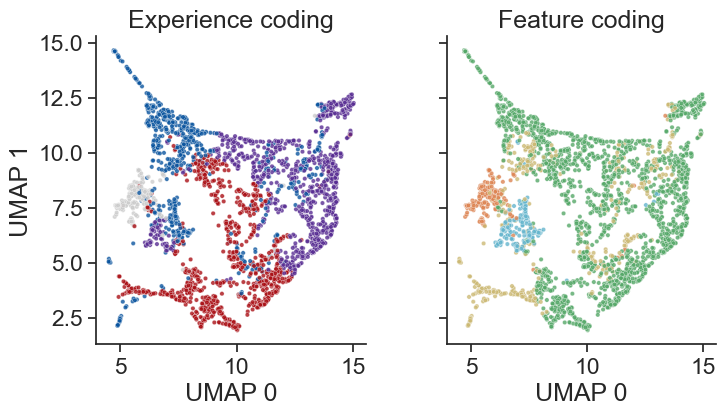

In [ ]:
figsize = (8, 4)

fig, ax = plt.subplots(1, 2, figsize=figsize, sharex=True, sharey=True)

umap_df['labels'] = meaningful_labels
ax[0] = sns.scatterplot(data=umap_df, x='x', y='y', s=10, ax=ax[0], #label=labels,
                     color=exp_colors, markers=markers, alpha=0.8)
ax[0].set_title('Experience coding')
ax[1] = sns.scatterplot(data=umap_df, x='x', y='y', s=10, ax=ax[1], #label=labels,
                     color=feature_colors, markers=markers, alpha=0.8)
ax[1].set_title('Feature coding')
ax[0].set_xlabel('UMAP 0')
ax[1].set_xlabel('UMAP 0')
ax[0].set_ylabel('UMAP 1')
plt.subplots_adjust(wspace=0.3)

/var/folders/1t/06qd1ncj5q90vctbvq586lmh0000gp/T/ipykernel_54244/1518427512.py:23: UserWarning: 
The palette list has fewer values (3) than needed (11) and will cycle, which may produce an uninterpretable plot.
  ax[2] = sns.scatterplot(data=umap_df, x='x', y='y', s=10, ax=ax[2], #label=labels,


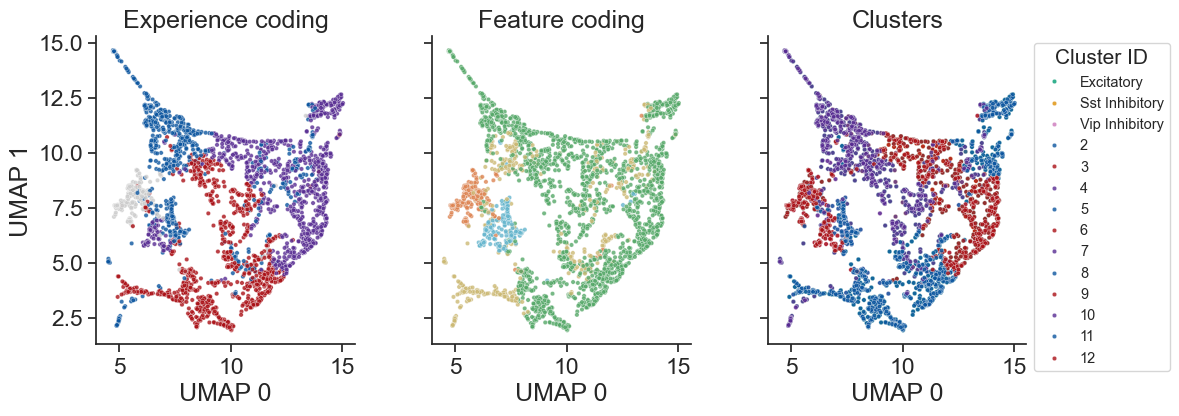

In [ ]:
figsize = (12, 4)

fig, ax = plt.subplots(1, 3, figsize=figsize, sharex=True, sharey=True)

ax[0] = sns.scatterplot(data=umap_df, x='x', y='y', s=10, ax=ax[0], #label=labels,
                     color=exp_colors, markers=markers, alpha=0.8)
ax[0].set_title('Experience coding')
ax[1] = sns.scatterplot(data=umap_df, x='x', y='y', s=10, ax=ax[1], #label=labels,
                     color=feature_colors, markers=markers, alpha=0.8)
ax[1].set_title('Feature coding')
ax[0].set_xlabel('UMAP 0')
ax[1].set_xlabel('UMAP 0')
ax[0].set_ylabel('UMAP 1')

ax[2] = sns.scatterplot(data=umap_df, x='x', y='y', s=10, ax=ax[2], hue_order=cell_types,
                     hue='cell_type', markers=markers, palette=utils.get_cell_type_colors(), alpha=0.8)
ax[2].set_title('Cell types')
ax[2].set_xlabel('UMAP 0')
ax[2].set_ylabel('UMAP 1')
ax[2].legend(title='Cell type', bbox_to_anchor=(1, 1), fontsize='xx-small', title_fontsize='small')
plt.subplots_adjust(wspace=0.3)

ax[2] = sns.scatterplot(data=umap_df, x='x', y='y', s=10, ax=ax[2], #label=labels,
                     hue='cluster_id', markers=markers, palette=sns.color_palette('hls', 12), alpha=0.8)
ax[2].set_title('Clusters')
ax[2].set_xlabel('UMAP 0')
ax[2].set_ylabel('UMAP 1')
ax[2].legend(title='Cluster ID', bbox_to_anchor=(1, 1), fontsize='xx-small', title_fontsize='small')
plt.subplots_adjust(wspace=0.3)

#### Try with new colors for specific cluster types

In [ ]:
cluster_id_labels = ['cluster '+str(main_cluster_meta.loc[cell_specimen_id]['cluster_id']) for cell_specimen_id in main_cluster_meta.index.values]

labels_dict = {1: 'other', # non coding - gray
                2: 'novelty enhanced', # novel image coding - red #AB0F15
                3: 'novel image coding', # persistent novel image coding -  reddish purple #A2258F
                4: 'familiar image coding', # familiar image coding - blue #0B549D
                5: 'other', # weird coding - gray
                6: 'novelty suppressed', # novelty suppression - light red #E38686
                7: 'other', # everything coding gray
                8: 'familiar omission coding', # omission coding during familiar - light blue #71A9DE
                9: 'novel+ omission coding', # omission coding during novel+ - light purple #9A79C9
                10: 'task coding', # task coding during familiar - yellow #DBD689
                11: 'other', # task coding during novel - gray
                12: 'behavior coding', # behavior coding - orange #FAB171
                }
labels = [labels_dict[main_cluster_meta.loc[cell_specimen_id]['cluster_id']] for cell_specimen_id in main_cluster_meta.index.values]


# gray = #BFBFBF
clutster_colors_dict = {1: '#BFBFBF', # non coding - gray #BFBFBF
                2: '#AB0F15', # novel image coding - red #AB0F15
                3: '#A2258F', # persistent novel image coding -  reddish purple #A2258F
                4: '#0B549D', # familiar image coding - blue #0B549D
                5: '#BFBFBF', # weird coding - gray
                6: '#E38686', # novelty suppression - light red #E38686
                7: '#BFBFBF', # everything coding gray
                8: '#71A9DE', # omission coding during familiar - light blue #71A9DE
                9: '#9A79C9', # omission coding during novel+ - light purple #9A79C9
                10: '#DBD689', # task coding during familiar - yellow #DBD689
                11: '#BFBFBF', # task coding during novel - gray
                12: '#FAB171', # behavior coding - orange #FAB171
                }
new_colors = [clutster_colors_dict[main_cluster_meta.loc[cell_specimen_id]['cluster_id']] for cell_specimen_id in main_cluster_meta.index.values]


markers_dict = {'Exc': 'o', # '^'
                'Sst': 's', # 'o'
                'Vip': 'd'}

markers = [markers_dict[main_cluster_meta.loc[cell_specimen_id]['cell_type'][:3]] for cell_specimen_id in main_cluster_meta.index.values]

In [ ]:
umap_df['cluster_id'] = [main_cluster_meta.loc[cell_specimen_id]['cluster_id'] for cell_specimen_id in main_cluster_meta.index.values]
umap_df['cluster_label'] = [labels_dict[main_cluster_meta.loc[cell_specimen_id]['cluster_id']] for cell_specimen_id in main_cluster_meta.index.values]
umap_df['cluster_id'] = ['cluster '+str(main_cluster_meta.loc[cell_specimen_id]['cluster_id']) for cell_specimen_id in main_cluster_meta.index.values]
umap_df['cell_type'] = [cell_type for cell_type in main_cluster_meta.cell_type.values]
umap_df.head()

,x,y,cluster_id,cell_type,labels,cluster_label
cell_specimen_id,,,,,,
1086489847,4.780380,7.625232,cluster 12,Vip Inhibitory,behavior coding,behavior coding
1086489860,9.371953,2.737884,cluster 2,Vip Inhibitory,novelty enhanced,novelty enhanced
1086489891,4.785028,7.619345,cluster 12,Vip Inhibitory,behavior coding,behavior coding
1086489976,6.144250,11.332527,cluster 4,Sst Inhibitory,familiar image coding,familiar image coding
1086490002,9.028252,10.901272,cluster 4,Sst Inhibitory,familiar image coding,familiar image coding


In [ ]:
red = sns.color_palette('Reds_r', 6).as_hex()[0]
blue = sns.color_palette('Blues_r', 6).as_hex()[0]
purple = sns.color_palette('Purples_r', 6).as_hex()[0]
print(red, blue, purple)

red = sns.color_palette('Reds_r', 6).as_hex()[2]
blue = sns.color_palette('Blues_r', 6).as_hex()[2]
purple = sns.color_palette('Purples_r', 6).as_hex()[2]
print(red, blue, purple)

#aa1016 #0b559f #572c92
#f44f39 #539ecd #8d89c0


In [ ]:
# hue_order = umap_df.cluster_label.unique()
hue_order = [ 'novelty enhanced', 'novelty suppressed',
             'novel image coding', 'familiar image coding', 
             'novel+ omission coding','familiar omission coding', 
             'task coding', 'behavior coding', 'other']

palette = ['#aa1016', # novelty enhanced - red #AB0F15, #aa1016 
           '#55a868', # novelty suppressed - light red #E38686, #fc8161, pink #E68C8F, green #55a868
            '#572c92', # novel image coding -  purple #A2258F, #572c92
            '#0b559f', # familiar image coding - blue #0B549D, #0b559f 
            '#8d89c0', # omission coding during novel+ - light purple #9A79C9, #afaed4
            '#539ecd', # omission coding during familiar - light blue #71A9DE, #89bedc 
            '#ccb974', # task coding during familiar - yellow #DBD689
            '#dd8452', # behavior coding - orange #FAB171
            '#BFBFBF',] # non coding - gray #BFBFBF



Text(0.5, 1.0, 'Main clusters')

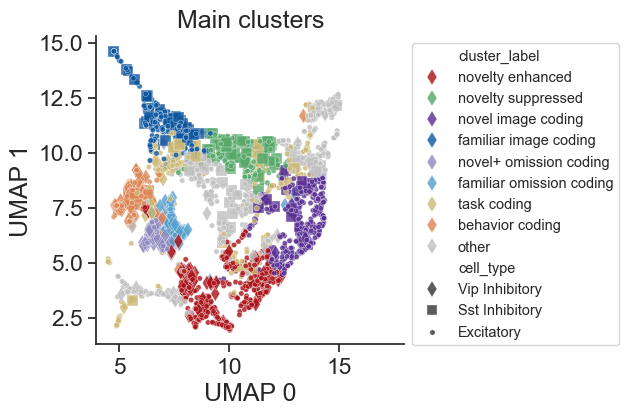

In [ ]:
figsize = (7, 4)
fig, ax = plt.subplots(figsize=figsize)

markers_dict = {'Excitatory': '.', # '^'
                'Sst Inhibitory': 's', # 'o', 's'
                'Vip Inhibitory': 'd'}

ax = sns.scatterplot(data=umap_df, x='x', y='y', s=60, ax=ax, #label=labels,
                     hue='cluster_label', hue_order=hue_order, style='cell_type', 
                     palette=palette, markers=markers_dict, linewidth=0.3, alpha=0.8, edgecolor='w')
ax.set_xlabel('UMAP 0')
ax.set_ylabel('UMAP 1')
ax.axis('square')
ax.legend(fontsize='xx-small', title_fontsize='xx-small',  bbox_to_anchor=(1,1))
ax.set_title('Main clusters')

#### pie charts

In [ ]:
labels_dict = {1: 'non-coding', # non coding - gray
                2: 'novelty enhanced', # novel image coding - red #AB0F15
                3: 'novel image coding', # persistent novel image coding -  reddish purple #A2258F
                4: 'familiar image coding', # familiar image coding - blue #0B549D
                5: 'novel image coding', # weird coding -reddish purple
                6: 'novelty suppressed', # novelty suppression - light red #E38686
                7: 'unselective', # everything coding gray
                8: 'familiar omission coding', # omission coding during familiar - light blue #71A9DE
                9: 'novel+ omission coding', # omission coding during novel+ - light purple #9A79C9
                10: 'task coding', # task coding during familiar - yellow #DBD689
                11: 'task coding', # task coding during novel - gray
                12: 'behavior coding', # behavior coding - orange #FAB171
                }
labels = [labels_dict[main_cluster_meta.loc[cell_specimen_id]['cluster_id']] for cell_specimen_id in main_cluster_meta.index.values]


In [ ]:
# hue_order = umap_df.cluster_label.unique()
hue_order = [ 'novelty enhanced', 'novelty suppressed',
             'novel image coding', 'familiar image coding', 
             'novel+ omission coding','familiar omission coding', 
             'task coding', 'behavior coding', 'unselective', 'non-coding']

palette = ['#aa1016', # novelty enhanced - red #AB0F15, #aa1016 
           '#55a868', # novelty suppressed - light red #E38686, #fc8161, pink #E68C8F, green #55a868
            '#572c92', # novel image coding -  purple #A2258F, #572c92
            '#0b559f', # familiar image coding - blue #0B549D, #0b559f 
            '#8d89c0', # omission coding during novel+ - light purple #9A79C9, #afaed4
            '#539ecd', # omission coding during familiar - light blue #71A9DE, #89bedc 
            '#ccb974', # task coding during familiar - yellow #DBD689
            '#dd8452', # behavior coding - orange #FAB171
            '#BFBFBF', # unselective
            '#BFBFBF',] # non-coding - gray #BFBFBF


In [ ]:
# get saved umap results
umap_df = processing.get_umap_results(feature_matrix, cluster_meta, save_dir=data_dir, suffix='')
umap_df['cell_specimen_id'] = cluster_meta.index.values
umap_df = umap_df.set_index('cell_specimen_id')

umap_df['cluster_id'] = [cluster_meta.loc[cell_specimen_id]['cluster_id'] for cell_specimen_id in cluster_meta.index.values]
umap_df['cluster_label'] = [labels_dict[cluster_meta.loc[cell_specimen_id]['cluster_id']] for cell_specimen_id in cluster_meta.index.values]
umap_df['cluster_id'] = ['cluster '+str(cluster_meta.loc[cell_specimen_id]['cluster_id']) for cell_specimen_id in cluster_meta.index.values]
umap_df['cell_type'] = [cell_type for cell_type in cluster_meta.cell_type.values]
umap_df.head()

loading umap results from /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_clustering_results/umap_results_df.h5


,x,y,cluster_id,cluster_label,cell_type
cell_specimen_id,,,,,
1086489847,4.780380,7.625232,cluster 12,behavior coding,Vip Inhibitory
1086489860,9.371953,2.737884,cluster 2,novelty enhanced,Vip Inhibitory
1086489891,4.785028,7.619345,cluster 12,behavior coding,Vip Inhibitory
1086489976,6.144250,11.332527,cluster 4,familiar image coding,Sst Inhibitory
1086490002,9.028252,10.901272,cluster 4,familiar image coding,Sst Inhibitory


In [ ]:
cluster_counts = umap_df.groupby(['cell_type', 'cluster_label']).count().rename(columns={'cluster_id':'n_cluster'})[['n_cluster']].reset_index()
cre_counts = umap_df.groupby(['cell_type']).count().rename(columns={'cluster_id':'n_cre'})[['n_cre']].reset_index()
counts = cluster_counts.merge(cre_counts, on='cell_type')
counts['fraction'] = counts['n_cluster']/counts['n_cre']
counts

,cell_type,cluster_label,n_cluster,n_cre,fraction
0,Excitatory,behavior coding,128,3298,0.038811
1,Excitatory,familiar image coding,313,3298,0.094906
2,Excitatory,familiar omission coding,25,3298,0.007580
3,Excitatory,non-coding,722,3298,0.218921
4,Excitatory,novel image coding,687,3298,0.208308
5,Excitatory,novel+ omission coding,29,3298,0.008793
6,Excitatory,novelty enhanced,611,3298,0.185264
7,Excitatory,novelty suppressed,177,3298,0.053669
8,Excitatory,task coding,402,3298,0.121892
9,Excitatory,unselective,204,3298,0.061856


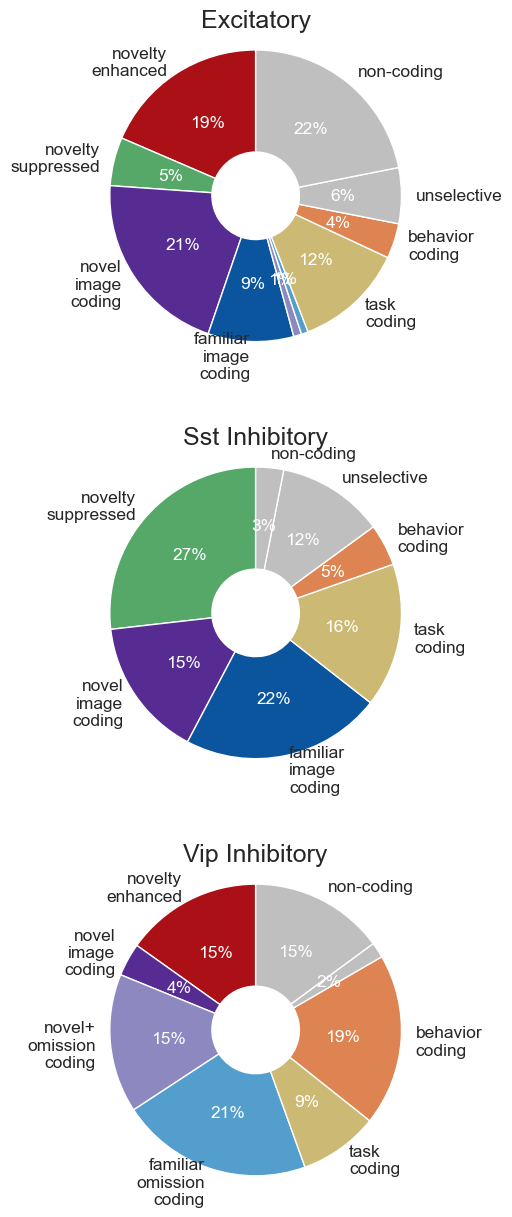

In [ ]:
figsize = (5, 15)
fig, ax = plt.subplots(3, 1, figsize=figsize)

for i, cell_type in enumerate(cell_types): 
    # get data for this cell type, with cluster labels & colors in a specific order
    data = counts[counts.cell_type==cell_type]
    fractions = []
    colors = []
    cluster_labels = []
    for c, cluster_label in enumerate(hue_order): 
        tmp = data[data.cluster_label==cluster_label]
        if len(tmp)>0: 
            fractions.append(tmp.fraction.values[0])
            colors.append(palette[c])
            if tmp.fraction.values[0]<=0.03: 
                label = ''
            else: 
                label = cluster_label.replace(' ','\n')
            cluster_labels.append(label)

    # plot it 
    wedges, texts, autotexts = ax[i].pie(fractions, 
                                        labels=cluster_labels, 
                                        autopct='%.0f%%',
                                        startangle=90, 
                                        wedgeprops={'width': 0.7, 'edgecolor': 'white'},   
                                        textprops={'size': 'x-small'},
                                        colors=colors) # Use a Seaborn color palette
    ax[i].axis('equal') 
    ax[i].set_title(cell_type)
    for autotext in autotexts:
        autotext.set_color('white')

    # Equal aspect ratio ensures that pie is drawn as a circle.
plt.subplots_adjust(hspace=0.3)

### Composite figure for graphical abstract

Combines the two data elements from this notebook — the **UMAP cluster scatter**
("Main clusters", cell above) and the **cell-type pie charts** — into a single
figure laid out like the bottom section of slide 1 of *VBO figures - revised v6*:
large UMAP on the left, the three cell-type pies stacked vertically on the right.
No panel letters (graphical-abstract style). Trace insets, the neuron schematic,
and the section title on the slide are added separately in PowerPoint.

Self-contained: rebuilds both the scatter table (cluster-1 + far outliers removed,
scatter label scheme) and the pie counts (full population, pie label scheme) from
`cluster_meta`, so it does not depend on whichever `umap_df` survived the cells above.
Layout knobs are constants at the top of the cell.

In [ ]:
import matplotlib.gridspec as gridspec

# ---------------- layout knobs (tweak between renders) ----------------
FIGSIZE          = (13, 6.5)
WIDTH_RATIOS     = (2.2, 1.0)   # UMAP : pie column
PIE_WSPACE       = 0.02         # gap between UMAP and pie column
PIE_HSPACE       = 0.6          # vertical gap between stacked pies
UMAP_MARKER_SIZE = 60
pie_cell_types   = ['Vip Inhibitory', 'Sst Inhibitory', 'Excitatory']  # top -> bottom (matches slide)

# ---------------- scatter label scheme (cells 16/19) ----------------
scatter_labels_dict = {1: 'other', 2: 'novelty enhanced', 3: 'novel image coding',
                       4: 'familiar image coding', 5: 'other', 6: 'novelty suppressed',
                       7: 'other', 8: 'familiar omission coding', 9: 'novel+ omission coding',
                       10: 'task coding', 11: 'other', 12: 'behavior coding'}
scatter_hue_order = ['novelty enhanced', 'novelty suppressed', 'novel image coding',
                     'familiar image coding', 'novel+ omission coding', 'familiar omission coding',
                     'task coding', 'behavior coding', 'other']
scatter_palette = ['#aa1016', '#55a868', '#572c92', '#0b559f', '#8d89c0', '#539ecd',
                   '#ccb974', '#dd8452', '#BFBFBF']
markers_dict = {'Excitatory': '.', 'Sst Inhibitory': 's', 'Vip Inhibitory': 'd'}

# ---------------- pie label scheme (cells 22/23) ----------------
pie_labels_dict = {1: 'non-coding', 2: 'novelty enhanced', 3: 'novel image coding',
                   4: 'familiar image coding', 5: 'novel image coding', 6: 'novelty suppressed',
                   7: 'unselective', 8: 'familiar omission coding', 9: 'novel+ omission coding',
                   10: 'task coding', 11: 'task coding', 12: 'behavior coding'}
pie_hue_order = ['novelty enhanced', 'novelty suppressed', 'novel image coding',
                 'familiar image coding', 'novel+ omission coding', 'familiar omission coding',
                 'task coding', 'behavior coding', 'unselective', 'non-coding']
pie_palette = ['#aa1016', '#55a868', '#572c92', '#0b559f', '#8d89c0', '#539ecd',
               '#ccb974', '#dd8452', '#BFBFBF', '#BFBFBF']

# ---------------- rebuild scatter table (filtered; cells 11-19) ----------------
scatter_umap = processing.get_umap_results(feature_matrix, cluster_meta, save_dir=data_dir, suffix='')
scatter_umap['cell_specimen_id'] = cluster_meta.index.values
scatter_umap = scatter_umap.set_index('cell_specimen_id')
_meta = cluster_meta[cluster_meta.cluster_id != 1]          # drop non-coding outlier cluster
scatter_umap = scatter_umap.loc[_meta.index.values]
scatter_umap = scatter_umap[scatter_umap.x < 16]           # drop far outliers
_meta = _meta.loc[scatter_umap.index.values]
scatter_umap['cluster_label'] = [scatter_labels_dict[_meta.loc[csid]['cluster_id']]
                                 for csid in scatter_umap.index.values]
scatter_umap['cell_type'] = _meta['cell_type'].values

# ---------------- rebuild pie counts (full population; cells 24-25) ----------------
pie_umap = processing.get_umap_results(feature_matrix, cluster_meta, save_dir=data_dir, suffix='')
pie_umap['cell_specimen_id'] = cluster_meta.index.values
pie_umap = pie_umap.set_index('cell_specimen_id')
pie_umap['cluster_label'] = [pie_labels_dict[cluster_meta.loc[csid]['cluster_id']]
                             for csid in cluster_meta.index.values]
pie_umap['cell_type'] = cluster_meta['cell_type'].values
cluster_counts = pie_umap.groupby(['cell_type', 'cluster_label']).size().reset_index(name='n_cluster')
cre_counts = pie_umap.groupby('cell_type').size().reset_index(name='n_cre')
counts = cluster_counts.merge(cre_counts, on='cell_type')
counts['fraction'] = counts['n_cluster'] / counts['n_cre']

# ---------------- figure ----------------
fig = plt.figure(figsize=FIGSIZE)
outer = gridspec.GridSpec(1, 2, width_ratios=WIDTH_RATIOS, wspace=PIE_WSPACE)
ax_umap = fig.add_subplot(outer[0, 0])
pie_gs = gridspec.GridSpecFromSubplotSpec(3, 1, subplot_spec=outer[0, 1], hspace=PIE_HSPACE)
pie_axes = [fig.add_subplot(pie_gs[i, 0]) for i in range(3)]

# UMAP scatter (mirrors the "Main clusters" cell)
sns.scatterplot(data=scatter_umap, x='x', y='y', s=UMAP_MARKER_SIZE, ax=ax_umap,
                hue='cluster_label', hue_order=scatter_hue_order,
                style='cell_type', palette=scatter_palette, markers=markers_dict,
                linewidth=0.3, alpha=0.8, edgecolor='w')
ax_umap.set_xlabel('UMAP 0')
ax_umap.set_ylabel('UMAP 1')
ax_umap.axis('square')
ax_umap.legend(fontsize='xx-small', title_fontsize='xx-small',
               bbox_to_anchor=(0.0, 1.0), loc='upper left', framealpha=0.6)

# pies (mirrors the pie-chart cell, one cell type per row)
for ax, cell_type in zip(pie_axes, pie_cell_types):
    data = counts[counts.cell_type == cell_type]
    fractions, colors, cluster_labels = [], [], []
    for c, cluster_label in enumerate(pie_hue_order):
        tmp = data[data.cluster_label == cluster_label]
        if len(tmp) > 0:
            fractions.append(tmp.fraction.values[0])
            colors.append(pie_palette[c])
            cluster_labels.append('' if tmp.fraction.values[0] <= 0.03
                                  else cluster_label.replace(' ', '\n'))
    wedges, texts, autotexts = ax.pie(fractions, labels=cluster_labels, autopct='%.0f%%',
                                      startangle=90,
                                      wedgeprops={'width': 0.7, 'edgecolor': 'white'},
                                      textprops={'size': 'x-small'}, colors=colors)
    ax.axis('equal')
    ax.set_title(cell_type)
    for autotext in autotexts:
        autotext.set_color('white')

fig.savefig(os.path.join(save_dir, 'graphical_abstract_composite.png'), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(save_dir, 'graphical_abstract_composite.pdf'), bbox_inches='tight')
plt.show()
